### DENGUE NO BRASIL - ANÁLISE DOS CASOS REPORTADOS

Base de dados disponibilizada na pós-graduação em Data Analytics pela Fiap

In [1]:
import pandas as pd          # manipulação e análise de dados em tabelas (DataFrames)
import geopandas as gpd      # como o pandas, mas para dados com localização geográfica (mapas)
import numpy as np           # cálculos matemáticos, como logaritmos e sequências numéricas
import matplotlib.pyplot as plt  # criação de gráficos (barras, linhas, mapas, etc)
import seaborn as sns        # gráficos estatísticos com visual mais elaborado
import io                    # permite ler arquivos diretamente da memória, sem salvar no disco
import requests              # faz requisições HTTP para acessar APIs e sites
import sidrapy               # biblioteca para baixar dados do IBGE (SIDRA) direto no Python


In [2]:
# Lê o arquivo Excel com os dados de dengue e armazena em um DataFrame
df_dengue = pd.read_excel('Base de Dados Dengue.xlsx')


In [3]:
# Mostra as 5 primeiras linhas do DataFrame para entender como os dados estão organizados
df_dengue.head()


,municipio,uf,data_infeccoes,qtd_infeccoes
0,ALTA FLORESTA D'OESTE,RO,2013-01-01,34
1,ALTA FLORESTA D'OESTE,RO,2013-02-01,44
2,ALTA FLORESTA D'OESTE,RO,2013-03-01,15
3,ALTA FLORESTA D'OESTE,RO,2013-04-01,4
4,ALTA FLORESTA D'OESTE,RO,2013-05-01,3


In [4]:
# Exibe o tamanho do DataFrame: o primeiro número é a quantidade de linhas (registros) e o segundo é a quantidade de colunas
print(f'Tamanho do Dataset: {df_dengue.shape}')

Tamanho do Dataset: (728772, 4)


In [5]:
# Mostra o tipo de dado de cada coluna (int, float, object, datetime, etc.)
df_dengue.dtypes

municipio                 object
uf                        object
data_infeccoes    datetime64[ns]
qtd_infeccoes              int64
dtype: object

In [6]:
# Conta quantos valores nulos existem em cada coluna
df_dengue.isnull().sum()

municipio         0
uf                0
data_infeccoes    0
qtd_infeccoes     0
dtype: int64

In [7]:
# A coluna 'data_infeccoes' contém a data completa (dia/mês/ano)
# Aqui extraio apenas o ano e salvo em uma nova coluna chamada 'ano'
df_dengue['ano'] = df_dengue['data_infeccoes'].dt.year


In [8]:
# Agrupa os dados por estado (uf) e por ano
# Para cada combinação de estado + ano, soma a quantidade total de infecções
# O reset_index() transforma o resultado de volta em uma tabela normal
df_dengue_estado = df_dengue.groupby(['uf', 'ano'])['qtd_infeccoes'].sum().reset_index()

print(df_dengue_estado)


     uf   ano  qtd_infeccoes
0    AC  2013           1663
1    AC  2014           3630
2    AC  2015            941
3    AC  2016            459
4    AC  2017            937
..   ..   ...            ...
292  TO  2019           2919
293  TO  2020            498
294  TO  2021           3912
295  TO  2022           6743
296  TO  2023           1232

[297 rows x 3 columns]


In [9]:
# Agrupa os dados apenas por ano e soma o total de infecções de todo o Brasil
# Resultado: uma linha por ano com o total nacional de casos
df_total_ano = df_dengue.groupby('ano')['qtd_infeccoes'].sum().reset_index()

print(df_total_ano)


     ano  qtd_infeccoes
0   2013         437104
1   2014         230178
2   2015         534491
3   2016         326657
4   2017          43313
5   2018          61774
6   2019         421850
7   2020         319793
8   2021         248910
9   2022         580677
10  2023         618378


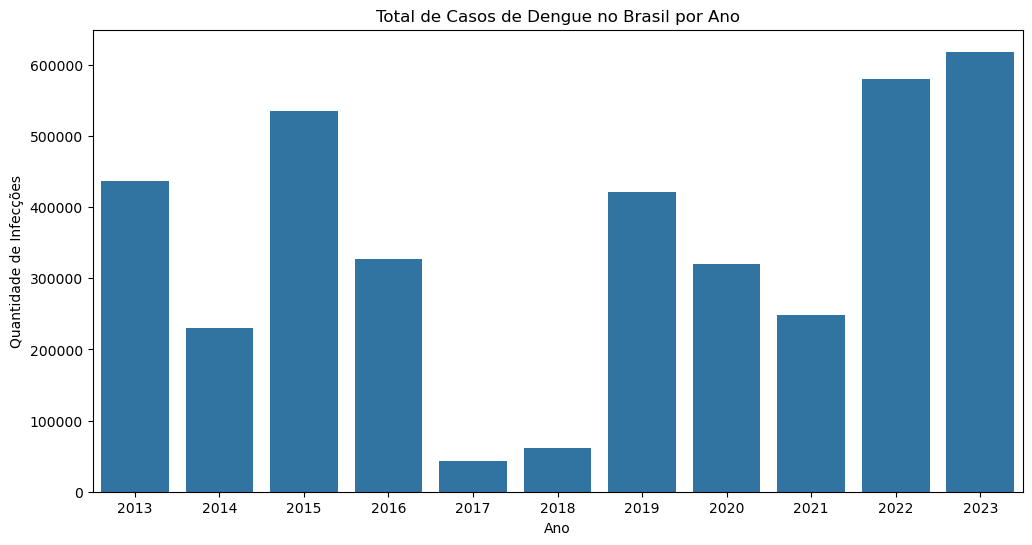

In [10]:
# Define o tamanho do gráfico (largura=12, altura=6)
plt.figure(figsize=(12, 6))

# Cria um gráfico de barras com o total de casos por ano
sns.barplot(data=df_total_ano, x='ano', y='qtd_infeccoes')

# Adiciona título e rótulos nos eixos
plt.title('Total de Casos de Dengue no Brasil por Ano')
plt.xlabel('Ano')
plt.ylabel('Quantidade de Infecções')

plt.show()


O gráfico revela um comportamento cíclico da dengue no Brasil. Nota-se uma queda acentuada nos casos em 2017 e 2018, seguida de retomada em 2019 e pelos maiores picos históricos em 2022 e 2023.

**Descoberta a partir de pesquisas em fontes científicas:**

A principal explicação para a redução de casos em 2017–2018 é imunológica. As grandes epidemias de dengue e zika em 2015–2016 imunizaram uma parcela significativa da população brasileira. Um estudo da Fiocruz mostrou que a epidemia de zika de 2015 pode ter gerado imunidade de rebanho cruzada para a dengue, o que é biologicamente possível porque ambos os vírus pertencem à mesma família (Flavivírus) e compartilham características genéticas semelhantes. Pesquisas indicam que essa imunidade de rebanho chegou a cerca de 50% em várias regiões das Américas após as pandemias de 2015–2016.

Além disso, a imunidade contra a dengue é permanente apenas para o mesmo sorotipo do vírus. Como existem quatro sorotipos diferentes, grandes epidemias tendem a ser seguidas por períodos de baixa incidência, até que a proteção coletiva diminua ou um novo sorotipo comece a circular, o que explica a volta dos casos em 2019 e os recordes de 2022–2023.

Outros fatores apontados em estudos incluem condições climáticas desfavoráveis ao mosquito em determinados períodos e a possibilidade de subnotificação em alguns estados.

Com base nisso, decidi enriquecer a base de dados com duas fontes externas: informações populacionais dos estados (IBGE) e dados históricos de precipitação por estado (NASA Power), para cruzar com os anos de menor incidência.


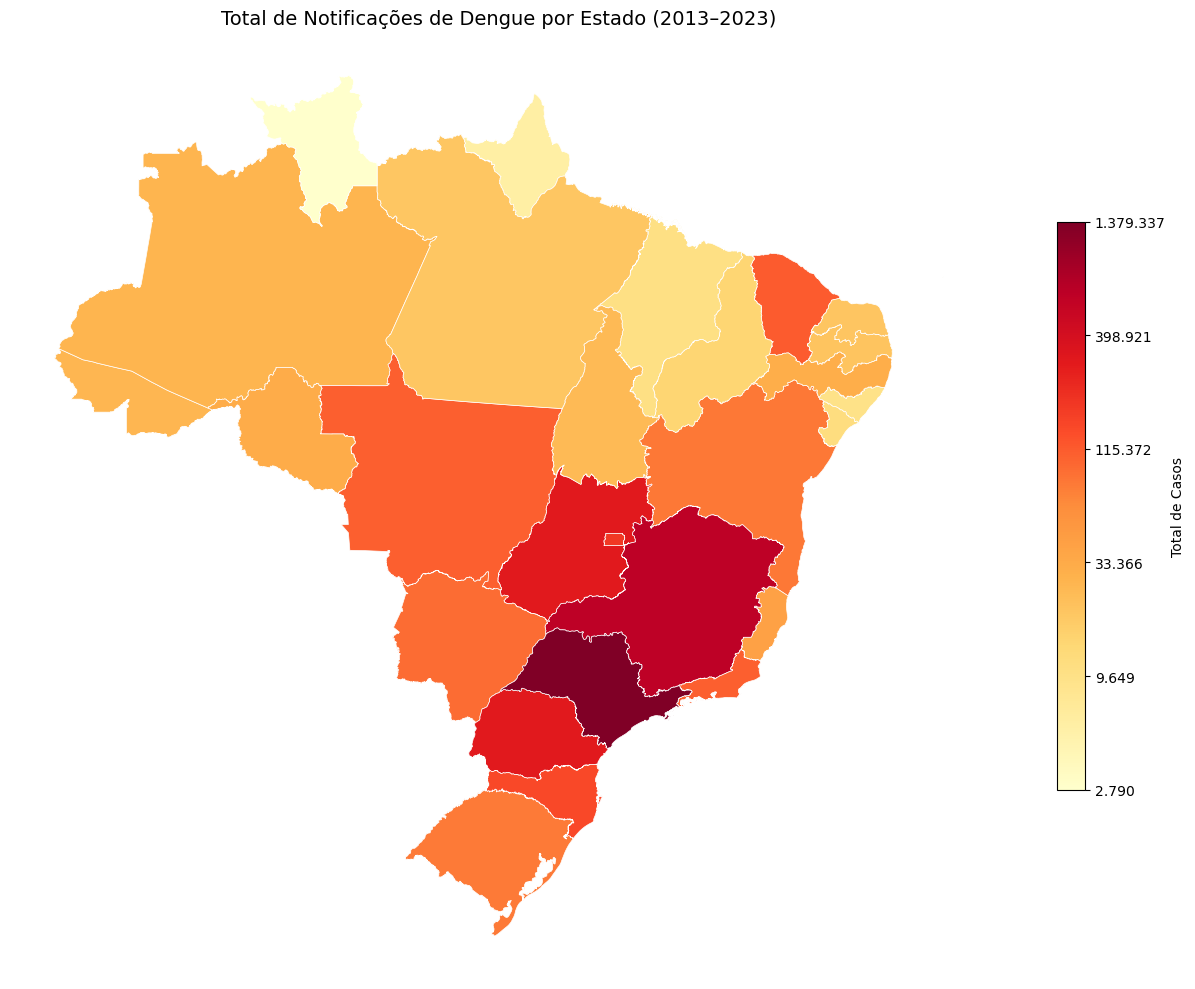

In [11]:
# ⚠️ Este bloco foi desenvolvido com auxílio de IA (assistente Claude/Anthropic) devido à complexidade das bibliotecas de visualização geográfica

from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# Faz o download do arquivo GeoJSON com os polígonos (formatos) de cada estado do Brasil
# GeoJSON é um formato de arquivo que guarda coordenadas geográficas
url_geojson = 'https://raw.githubusercontent.com/codeforgermany/click_that_hood/main/public/data/brazil-states.geojson'
response = requests.get(url_geojson)

# Lê o arquivo diretamente da memória, sem precisar salvar no computador
gdf_estados = gpd.read_file(io.BytesIO(response.content))

# Soma o total de infecções por estado em toda a série histórica
df_total_estado = df_dengue_estado.groupby('uf')['qtd_infeccoes'].sum().reset_index()

# Une o mapa geográfico com os dados de dengue usando a sigla do estado como chave
gdf_merged = gdf_estados.merge(df_total_estado, left_on='sigla', right_on='uf')

# Aplica escala logarítmica para evitar que estados com muitos casos (ex: SP) dominem completamente a escala de cores do mapa
# log1p é uma variação do logaritmo que funciona mesmo quando o valor é zero
gdf_merged['log_infeccoes'] = np.log1p(gdf_merged['qtd_infeccoes'])

# Cria o gráfico do mapa
fig, ax = plt.subplots(1, 1, figsize=(14, 10))
gdf_merged.plot(
    column='log_infeccoes',   # coluna que define a cor de cada estado
    cmap='YlOrRd',            # paleta de cores: amarelo → laranja → vermelho
    linewidth=0.5,            # espessura da borda entre estados
    edgecolor='white',        # cor da borda
    legend=False,             # a legenda será criada manualmente abaixo
    ax=ax
)

# Cria a legenda de cores manualmente para mostrar os valores reais (não logarítmicos)
norm = Normalize(vmin=gdf_merged['log_infeccoes'].min(), vmax=gdf_merged['log_infeccoes'].max())
sm = ScalarMappable(cmap='YlOrRd', norm=norm)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax, shrink=0.6)
cbar.set_label('Total de Casos')

# Define 6 pontos igualmente espaçados para os ticks da legenda
ticks_log = np.linspace(gdf_merged['log_infeccoes'].min(), gdf_merged['log_infeccoes'].max(), 6)
cbar.set_ticks(ticks_log)

# Converte os valores de volta da escala logarítmica para os números reais e formata com pontos como separadores de milhar (padrão brasileiro)
cbar.set_ticklabels([f"{int(np.expm1(t)):,}".replace(',', '.') for t in ticks_log])

ax.set_title('Total de Notificações de Dengue por Estado (2013–2023)', fontsize=14)
ax.axis('off')  # esconde os eixos de latitude/longitude
plt.tight_layout()
plt.show()


## Enriquecimento da base — API do IBGE


Para enriquecer a base com informações sobre os estados (nome completo, sigla da região e nome da região), utilizei a API pública de localidades do IBGE. Essa API retorna um JSON com todos os estados brasileiros e seus dados cadastrais, dispensando o download manual de arquivos.


In [12]:
# ⚠️ Desenvolvido com auxílio de IA

# Endereço da API do IBGE que retorna os dados de todos os estados brasileiros
url = 'https://servicodados.ibge.gov.br/api/v1/localidades/estados'

# Faz a requisição para a API e guarda a resposta
response = requests.get(url)

# Se a requisição falhar (ex: erro 404 ou 500), interrompe o código com uma mensagem de erro
response.raise_for_status()

# Converte a resposta (que vem em formato JSON) para um objeto Python (lista de dicionários)
dados = response.json()

# Transforma a lista de dicionários em uma tabela (DataFrame)
# O json_normalize 'achata' estruturas aninhadas, como 'regiao.sigla' e 'regiao.nome'
df_estados = pd.json_normalize(dados)

# Seleciona apenas as colunas que me interessam e renomeia para nomes mais claros
df_estados = df_estados[['id', 'sigla', 'nome', 'regiao.sigla', 'regiao.nome']]
df_estados = df_estados.rename(columns={
    'id':           'id_estado',
    'sigla':        'uf',
    'nome':         'nome_estado',
    'regiao.sigla': 'sigla_regiao',
    'regiao.nome':  'nome_regiao'
})

print(df_estados)


    id_estado  uf          nome_estado sigla_regiao   nome_regiao
0          11  RO             Rondônia            N         Norte
1          12  AC                 Acre            N         Norte
2          13  AM             Amazonas            N         Norte
3          14  RR              Roraima            N         Norte
4          15  PA                 Pará            N         Norte
5          16  AP                Amapá            N         Norte
6          17  TO            Tocantins            N         Norte
7          21  MA             Maranhão           NE      Nordeste
8          22  PI                Piauí           NE      Nordeste
9          23  CE                Ceará           NE      Nordeste
10         24  RN  Rio Grande do Norte           NE      Nordeste
11         25  PB              Paraíba           NE      Nordeste
12         26  PE           Pernambuco           NE      Nordeste
13         27  AL              Alagoas           NE      Nordeste
14        

In [13]:
# Une o DataFrame de dengue por estado com as informações geográficas do IBGE
# A coluna 'uf' (sigla do estado) é usada como chave de ligação entre as duas tabelas
# how='left' garante que todos os registros de dengue sejam mantidos mesmo que não haja correspondência na tabela do IBGE
df_dengue_estado_completo = pd.merge(df_dengue_estado, df_estados, on='uf', how='left')

df_dengue_estado_completo.head()


,uf,ano,qtd_infeccoes,id_estado,nome_estado,sigla_regiao,nome_regiao
0,AC,2013,1663,12,Acre,N,Norte
1,AC,2014,3630,12,Acre,N,Norte
2,AC,2015,941,12,Acre,N,Norte
3,AC,2016,459,12,Acre,N,Norte
4,AC,2017,937,12,Acre,N,Norte


## Enriquecimento da base — API SIDRA (IBGE) — Dados Populacionais


Para calcular a taxa de infecções por 100.000 habitantes, preciso da população de cada estado. Utilizei então a biblioteca sidrapy, que permite acessar diretamente as tabelas do IBGE pelo código da pesquisa, sem necessidade de download manual.

Os dados populacionais utilizados vêm do Censo Demográfico 2022 (tabela 4714 do SIDRA). Como essa base é referente ao ano de 2022, o cálculo da taxa será feito apenas para o ano de 2022.

- Fonte da pesquisa: https://sidra.ibge.gov.br/pesquisa/censo-demografico/demografico-2022/primeiros-resultados-populacao-e-domicilios
- Documentação da API: https://apisidra.ibge.gov.br/


In [14]:
# ⚠️ Desenvolvido com auxílio de IA

# Baixa a tabela 4714 do IBGE, que contém a população residente por estado no Censo 2022
df_populacao_estado = sidrapy.get_table(
    table_code='4714',          # código da tabela no SIDRA
    territorial_level='3',      # nível 3 = estados
    ibge_territorial_code='all',# todos os estados
    period='all'                # todos os períodos disponíveis
)

# A primeira linha retornada é um cabeçalho duplicado do próprio IBGE — removemos ela
df_populacao_estado = df_populacao_estado.iloc[1:]

# Filtra apenas as linhas onde o tipo de dado é 'População residente'
df_populacao_estado = df_populacao_estado[df_populacao_estado['D3N'] == 'População residente']

# Mantém apenas as colunas com o nome do estado e o valor da população
df_populacao_estado = df_populacao_estado[['D1N', 'V']]

# Renomeia as colunas para nomes mais legíveis
df_populacao_estado = df_populacao_estado.rename(columns={
    'D1N': 'estado',
    'V':   'populacao'
})

# Converte a coluna de população para número
# errors='coerce' transforma valores inválidos em NaN ao invés de gerar erro
df_populacao_estado['populacao'] = pd.to_numeric(df_populacao_estado['populacao'], errors='coerce')

df_populacao_estado.head(50)


,estado,populacao
1,Rondônia,1581196
4,Acre,830018
7,Amazonas,3941613
10,Roraima,636707
13,Pará,8120131
16,Amapá,733759
19,Tocantins,1511460
22,Maranhão,6776699
25,Piauí,3271199
28,Ceará,8794957


A base populacional do SIDRA é referente ao Censo de 2022, portanto o cálculo da taxa de infecções por 100.000 habitantes só pode ser feito de forma precisa para o ano de 2022. Nos próximos passos, vou:

1. Filtrar apenas os dados de dengue do ano de 2022
2. Unir com a tabela de população
3. Calcular a taxa: `(qtd_infeccoes / populacao) * 100.000`

Essa normalização é importante porque estados com populações maiores tendem a ter mais casos em números absolutos, mas isso não significa necessariamente maior risco per capita.


In [15]:
# Filtra apenas os registros do ano de 2022
df_dengue_2022 = df_dengue_estado_completo[df_dengue_estado_completo['ano'] == 2022]

# Une os dados de dengue 2022 com a tabela de população
# left_on e right_on indicam as colunas de cada tabela que serão usadas para a ligação
# drop(columns=['estado']) remove a coluna duplicada que veio da tabela de população
df_dengue_2022 = pd.merge(
    df_dengue_2022,
    df_populacao_estado,
    left_on='nome_estado',
    right_on='estado',
    how='left'
).drop(columns=['estado'])

# Calcula a taxa de infecções a cada 100.000 habitantes
# Fórmula: (total de casos / população do estado) × 100.000
df_dengue_2022['taxa_infeccoes_100k'] = (df_dengue_2022['qtd_infeccoes'] / df_dengue_2022['populacao']) * 100000

df_dengue_2022.head()


,uf,ano,qtd_infeccoes,id_estado,nome_estado,sigla_regiao,nome_regiao,populacao,taxa_infeccoes_100k
0,AC,2022,1888,12,Acre,N,Norte,830018,227.464947
1,AL,2022,1906,27,Alagoas,NE,Nordeste,3127683,60.939680
2,AM,2022,2590,13,Amazonas,N,Norte,3941613,65.709140
3,AP,2022,241,16,Amapá,N,Norte,733759,32.844572
4,BA,2022,7974,29,Bahia,NE,Nordeste,14141626,56.386727


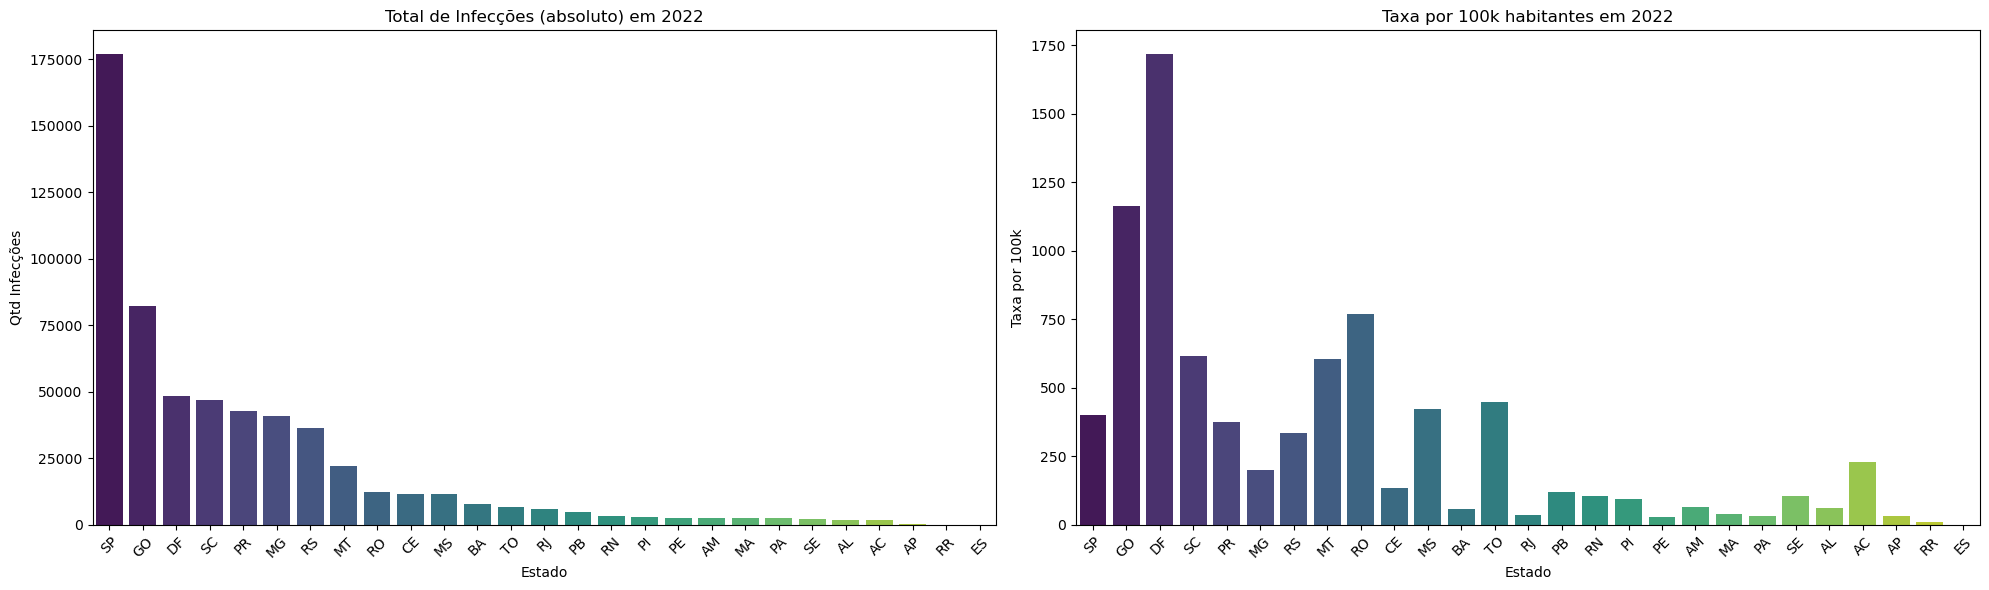

In [16]:
# Cria dois gráficos lado a lado para comparar casos absolutos e taxa por 100k em 2022
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

# Ordena os estados do maior para o menor número de infecções
df_dengue_2022 = df_dengue_2022.sort_values('qtd_infeccoes', ascending=False)

# Gráfico da esquerda: total de infecções em números absolutos
sns.barplot(data=df_dengue_2022, x='uf', y='qtd_infeccoes', hue='uf',
            palette='viridis', legend=False, ax=ax1)
ax1.set_title('Total de Infecções (absoluto) em 2022')
ax1.set_xlabel('Estado')
ax1.set_ylabel('Qtd Infecções')
ax1.tick_params(axis='x', rotation=45)  # rotaciona os nomes dos estados para não sobrepor

# Gráfico da direita: taxa de infecções por 100 mil habitantes
sns.barplot(data=df_dengue_2022, x='uf', y='taxa_infeccoes_100k', hue='uf',
            palette='viridis', legend=False, ax=ax2)
ax2.set_title('Taxa por 100k habitantes em 2022')
ax2.set_xlabel('Estado')
ax2.set_ylabel('Taxa por 100k')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


A comparação lado a lado é fundamental para uma análise mais justa entre os estados. Olhando apenas os números absolutos, estados populosos como SP e MG naturalmente se destacam. Mas ao analisar a taxa por 100.000 habitantes, outros estados ganham relevância, como DF, RO, SC, MT, MS, TO e AC, revelando um risco per capita muito maior do que os números brutos sugeriam.

Isso reforça a importância de sempre normalizar dados populacionais antes de comparar regiões com tamanhos diferentes.


## Enriquecimento da base — API NASA Power — Dados de Precipitação

Para investigar se a quantidade de chuvas tem relação com os casos de dengue, utilizei a API NASA Power, que fornece dados climáticos históricos por coordenada geográfica. Coletei a precipitação mensal (em mm) para a capital de cada estado brasileiro, cobrindo os anos de 2015 a 2023.

O dado utilizado é o PRECTOTCORR (precipitação total corrigida), disponível gratuitamente pela NASA.


In [17]:
# ⚠️ Desenvolvido com auxílio de IA

# Dicionário com a sigla de cada estado e as coordenadas (latitude e longitude) de sua capital
# Essas coordenadas são usadas para buscar os dados de chuva na API da NASA
capitais = {
    'AC': {'lat': -9.97499,  'lon': -67.8243},  # Rio Branco
    'AL': {'lat': -9.66599,  'lon': -35.735},   # Maceió
    'AP': {'lat':  0.0349,   'lon': -51.0694},  # Macapá
    'AM': {'lat': -3.10719,  'lon': -60.0261},  # Manaus
    'BA': {'lat': -12.9714,  'lon': -38.5014},  # Salvador
    'CE': {'lat': -3.71722,  'lon': -38.5433},  # Fortaleza
    'DF': {'lat': -15.7939,  'lon': -47.8828},  # Brasília
    'ES': {'lat': -20.3155,  'lon': -40.3128},  # Vitória
    'GO': {'lat': -16.6864,  'lon': -49.2643},  # Goiânia
    'MA': {'lat': -2.53874,  'lon': -44.2825},  # São Luís
    'MT': {'lat': -15.601,   'lon': -56.0974},  # Cuiabá
    'MS': {'lat': -20.4697,  'lon': -54.6201},  # Campo Grande
    'MG': {'lat': -19.9167,  'lon': -43.9345},  # Belo Horizonte
    'PA': {'lat': -1.45502,  'lon': -48.5024},  # Belém
    'PB': {'lat': -7.11509,  'lon': -34.8641},  # João Pessoa
    'PR': {'lat': -25.4284,  'lon': -49.2733},  # Curitiba
    'PE': {'lat': -8.04756,  'lon': -34.877},   # Recife
    'PI': {'lat': -5.08921,  'lon': -42.8016},  # Teresina
    'RJ': {'lat': -22.9068,  'lon': -43.1729},  # Rio de Janeiro
    'RN': {'lat': -5.7945,   'lon': -35.211},   # Natal
    'RS': {'lat': -30.0346,  'lon': -51.2177},  # Porto Alegre
    'RO': {'lat': -8.76183,  'lon': -63.9039},  # Porto Velho
    'RR': {'lat':  2.81954,  'lon': -60.6714},  # Boa Vista
    'SC': {'lat': -27.5954,  'lon': -48.548},   # Florianópolis
    'SP': {'lat': -23.5505,  'lon': -46.6333},  # São Paulo
    'SE': {'lat': -10.9472,  'lon': -37.0731},  # Aracaju
    'TO': {'lat': -10.1689,  'lon': -48.3317},  # Palmas
}

# Lista vazia para guardar os dados de chuva de cada estado
lista_dfs = []

# Percorre cada estado e faz uma requisição separada para a API da NASA
for uf, coord in capitais.items():

    # Parâmetros enviados para a API (o que quero buscar e de onde)
    params = {
        'parameters': 'PRECTOTCORR',  # tipo de dado: precipitação total corrigida
        'community':  'AG',           # perfil agrícola (um dos modos disponíveis na API)
        'longitude':  coord['lon'],   # longitude da capital do estado
        'latitude':   coord['lat'],   # latitude da capital do estado
        'start':      '2015',         # ano de início da série histórica
        'end':        '2023',         # ano de fim da série histórica
        'format':     'JSON'          # formato de retorno dos dados
    }

    # Faz a requisição para a API da NASA com os parâmetros definidos
    response = requests.get('https://power.larc.nasa.gov/api/temporal/monthly/point', params=params)

    # Converte a resposta para um dicionário Python
    dados = response.json()

    # Navega dentro do JSON para chegar nos valores mensais de precipitação
    valores_mensais = dados['properties']['parameter']['PRECTOTCORR']

    # Transforma o dicionário de valores em uma tabela (DataFrame)
    df_temp = pd.DataFrame(list(valores_mensais.items()), columns=['ano_mes', 'precipitacao_mm'])

    # Adiciona uma coluna com a sigla do estado para saber de onde veio cada linha
    df_temp['uf'] = uf

    # Adiciona o resultado deste estado na lista
    lista_dfs.append(df_temp)

# Junta os DataFrames de todos os estados em uma única tabela
df_chuva_estados = pd.concat(lista_dfs, ignore_index=True)

# Extrai o ano a partir dos 4 primeiros caracteres da coluna 'ano_mes' (ex: '201501' → '2015')
df_chuva_estados['ano'] = df_chuva_estados['ano_mes'].str[:4]

# Converte a coluna de ano para número inteiro
df_chuva_estados['ano'] = df_chuva_estados['ano'].astype(int)

# Converte a coluna de precipitação para número decimal
df_chuva_estados['precipitacao_mm'] = df_chuva_estados['precipitacao_mm'].astype(float)

# A API retorna um registro extra por ano com o total anual (código terminando em '13')
# Removo esse registro para trabalhar apenas com os 12 meses
df_chuva_estados = df_chuva_estados[~df_chuva_estados['ano_mes'].str.endswith('13')]

# Remove a coluna 'ano_mes' que não será mais necessária
df_chuva_estados = df_chuva_estados[['uf', 'ano', 'precipitacao_mm']]

# Agrupa por estado e ano, somando a precipitação de todos os meses para obter o total anual
df_chuva_anual = df_chuva_estados.groupby(['uf', 'ano'])['precipitacao_mm'].sum().reset_index()

# Ordena por estado e depois por ano
df_chuva_anual = df_chuva_anual.sort_values(by=['uf', 'ano']).reset_index(drop=True)

print(df_chuva_anual)


     uf   ano  precipitacao_mm
0    AC  2015            52.40
1    AC  2016            44.24
2    AC  2017            40.27
3    AC  2018            37.45
4    AC  2019            52.17
..   ..   ...              ...
238  TO  2019            37.10
239  TO  2020            41.92
240  TO  2021            51.93
241  TO  2022            49.41
242  TO  2023            39.82

[243 rows x 3 columns]


In [18]:
# Soma a precipitação de todos os estados por ano para obter o total nacional, isso permite comparar a chuva no Brasil inteiro com o número de casos de dengue
df_chuva_pais = df_chuva_estados.groupby('ano')['precipitacao_mm'].sum().reset_index()

df_chuva_pais.head()


,ano,precipitacao_mm
0,2015,1032.77
1,2016,1179.63
2,2017,1227.28
3,2018,1232.77
4,2019,1237.29


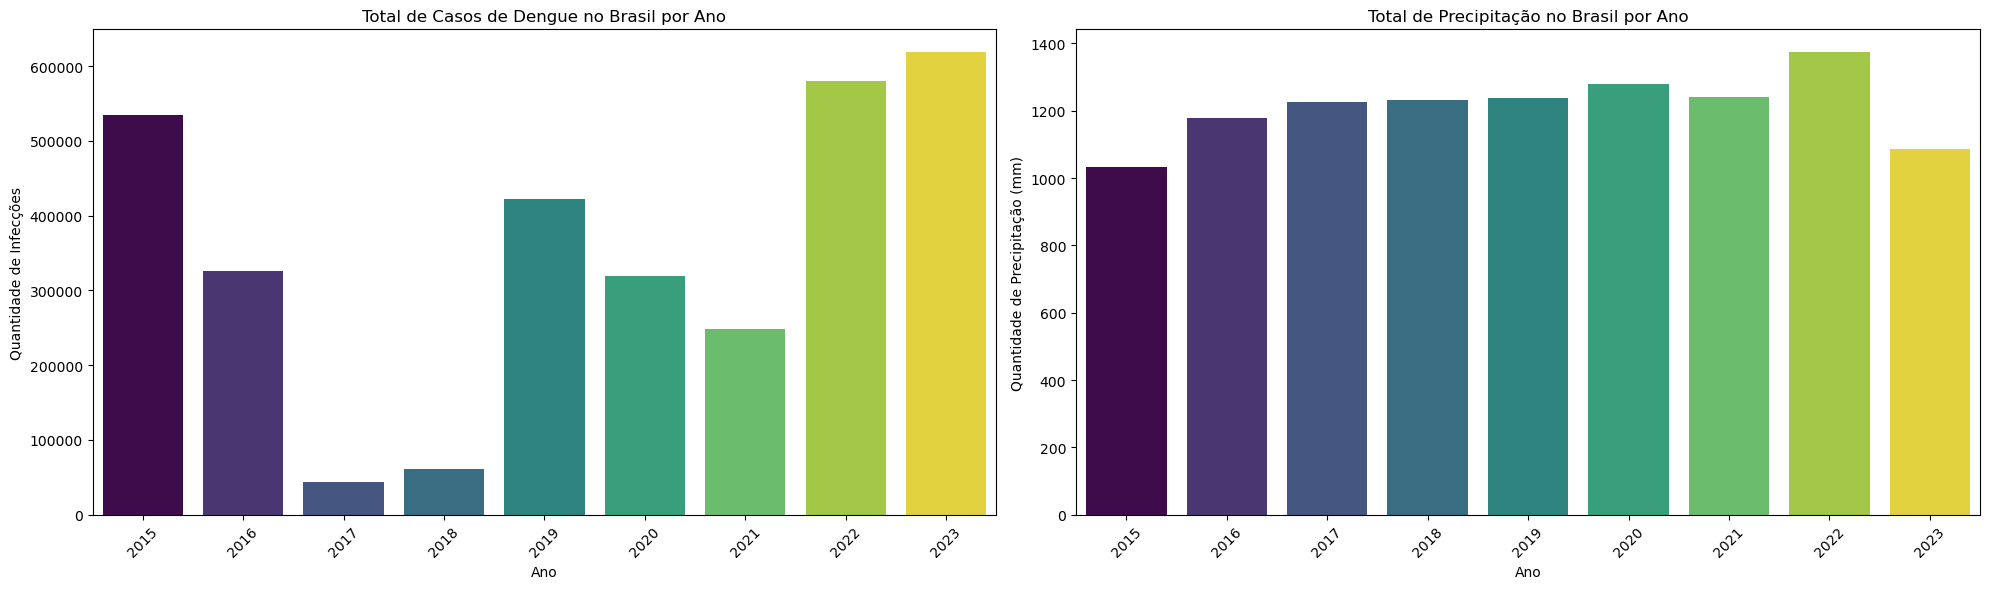

In [19]:
# Cria dois gráficos lado a lado: casos de dengue e precipitação no Brasil por ano
# O objetivo é verificar visualmente se houve queda de chuvas nos anos com menos dengue
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

# Filtra os dados de dengue a partir de 2015, alinhando com o período disponível na NASA
df_total_ano = df_total_ano[df_total_ano['ano'] >= 2015]

# Gráfico da esquerda: total de casos de dengue por ano
sns.barplot(data=df_total_ano, x='ano', y='qtd_infeccoes', hue='ano',
            palette='viridis', legend=False, ax=ax1)
ax1.set_title('Total de Casos de Dengue no Brasil por Ano')
ax1.set_xlabel('Ano')
ax1.set_ylabel('Quantidade de Infecções')
ax1.tick_params(axis='x', rotation=45)

# Gráfico da direita: total de precipitação no Brasil por ano
sns.barplot(data=df_chuva_pais, x='ano', y='precipitacao_mm', hue='ano',
            palette='viridis', legend=False, ax=ax2)
ax2.set_title('Total de Precipitação no Brasil por Ano')
ax2.set_xlabel('Ano')
ax2.set_ylabel('Quantidade de Precipitação (mm)')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


Com os dois gráficos lado a lado, fica claro que não houve redução de chuvas no Brasil nos anos de 2017 e 2018, a precipitação se manteve em níveis similares aos demais anos. Isso reforça que a queda nos casos de dengue nesse período foi causada principalmente pela imunidade de rebanho adquirida após as grandes epidemias de 2015–2016, e não por condições climáticas mais desfavoráveis ao mosquito.

Para aprofundar a análise, vou comparar agora a chuva e os casos de dengue por estado no ano de 2017, para verificar se ao menos em nível regional existe alguma correlação.


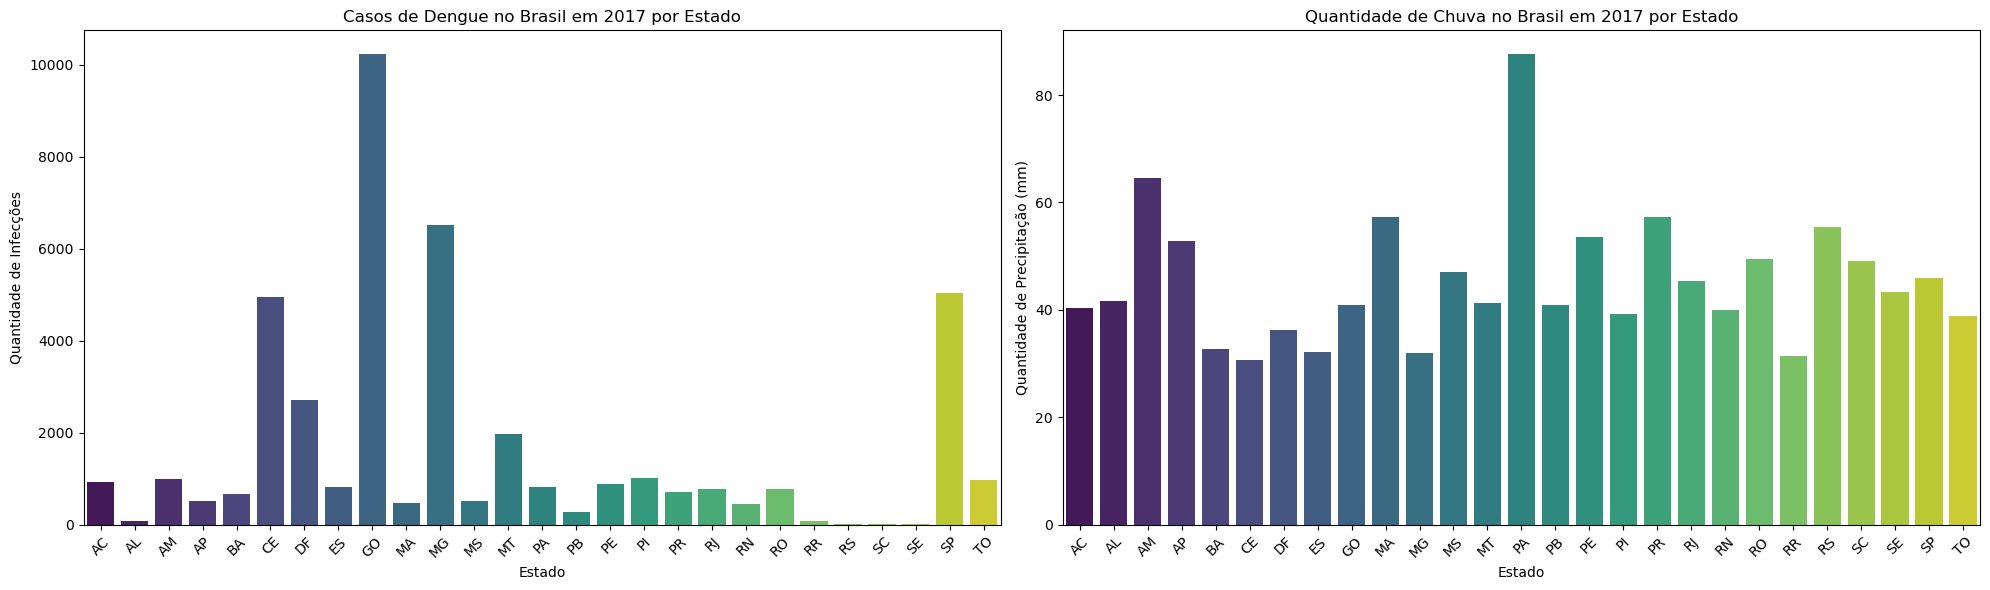

In [20]:
# Cria dois gráficos lado a lado: casos de dengue e precipitação por estado em 2017
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

# Filtra e ordena os dados de dengue de 2017 por estado (ordem alfabética)
df_dengue_2017 = df_dengue_estado_completo[df_dengue_estado_completo['ano'] == 2017]
df_dengue_2017 = df_dengue_2017.sort_values(by='uf', ascending=True)

# Gráfico da esquerda: casos de dengue por estado em 2017
sns.barplot(data=df_dengue_2017, x='uf', y='qtd_infeccoes', hue='uf',
            palette='viridis', legend=False, ax=ax1)
ax1.set_title('Casos de Dengue no Brasil em 2017 por Estado')
ax1.set_xlabel('Estado')
ax1.set_ylabel('Quantidade de Infecções')
ax1.tick_params(axis='x', rotation=45)

# Filtra e ordena os dados de chuva de 2017 por estado (mesma ordem do gráfico anterior)
df_chuva_2017 = df_chuva_anual[df_chuva_anual['ano'] == 2017]
df_chuva_2017 = df_chuva_2017.sort_values(by='uf', ascending=True)

# Gráfico da direita: precipitação por estado em 2017
sns.barplot(data=df_chuva_2017, x='uf', y='precipitacao_mm', hue='uf',
            palette='viridis', legend=False, ax=ax2)
ax2.set_title('Quantidade de Chuva no Brasil em 2017 por Estado')
ax2.set_xlabel('Estado')
ax2.set_ylabel('Quantidade de Precipitação (mm)')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


A comparação por estado em 2017 confirma a ausência de correlação direta entre chuva e dengue. Goiás, com chuvas medianas, foi o estado com mais casos. O Pará, com a maior precipitação do país (~90mm), apresentou pouquíssimos casos. Estados do Sul como RS e SC tiveram precipitação moderada e casos próximos de zero, o que pode estar associado ao clima mais frio, desfavorável ao Aedes aegypti.

A conclusão é que fatores estruturais locais, como saneamento, urbanização e presença de água parada, têm muito mais peso na disseminação da dengue do que o volume de chuva isoladamente.

Nos próximos passos, vou explorar a evolução histórica por estado de duas formas: um heatmap para uma visão geral, e um gráfico individual por estado para enxergar os ciclos de cada região.


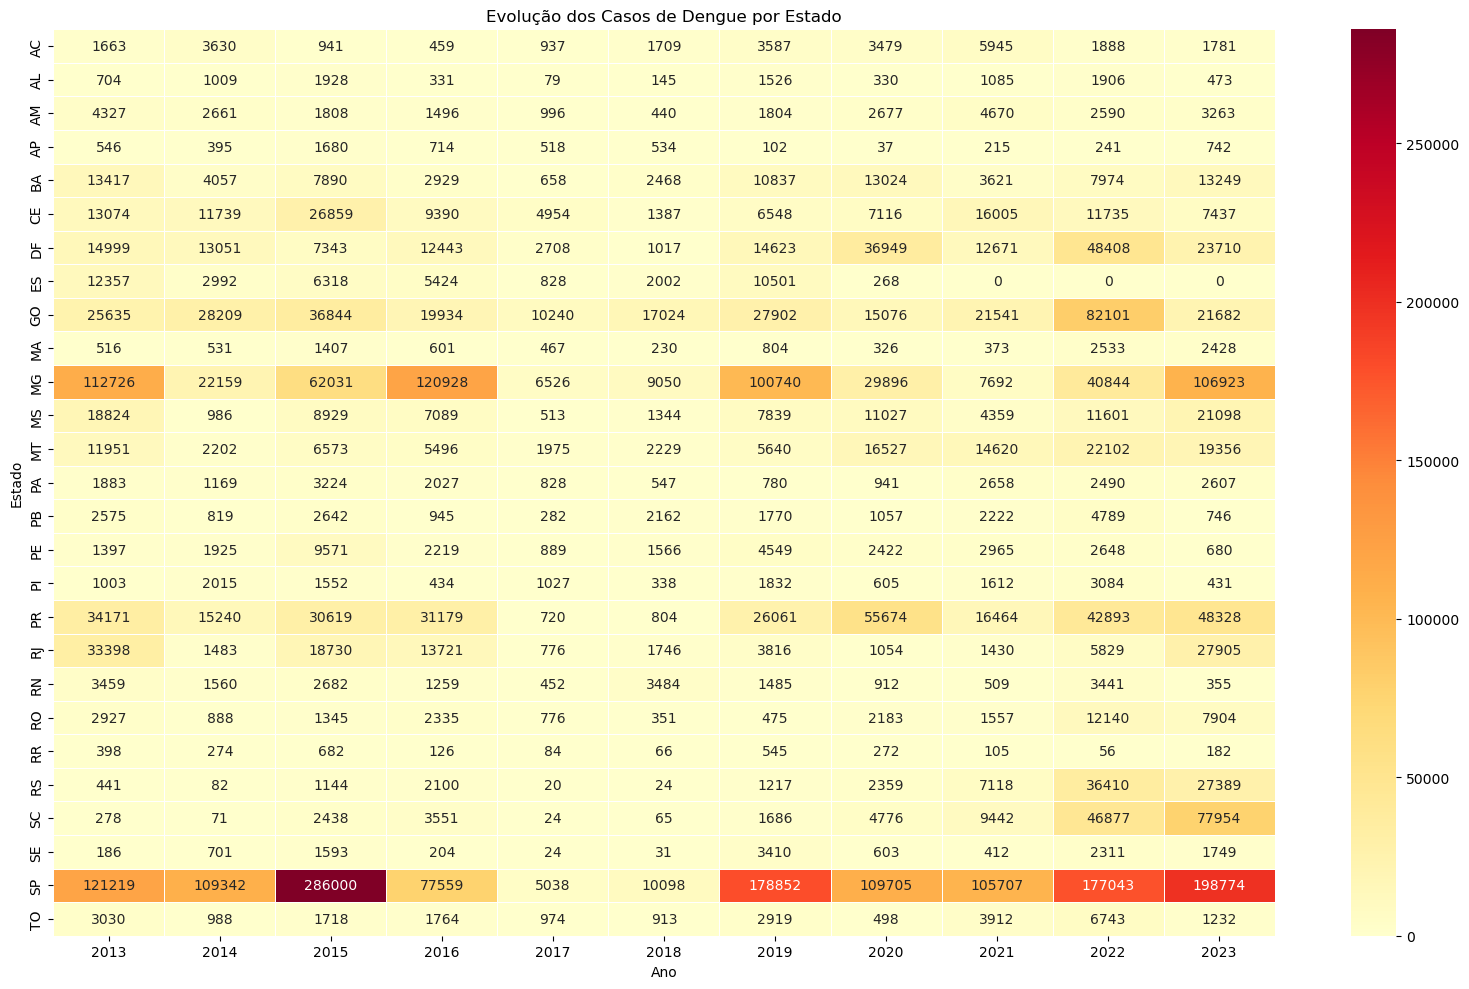

In [21]:
# Cria uma tabela pivot: estados nas linhas, anos nas colunas, casos como valores
# Isso organiza os dados no formato ideal para um heatmap
df_pivot = df_dengue_estado_completo.pivot(index='uf', columns='ano', values='qtd_infeccoes')

plt.figure(figsize=(16, 10))

# Plota o heatmap: quanto mais escuro/vermelho, maior o número de casos
sns.heatmap(
    df_pivot,
    cmap='YlOrRd',     # cores do amarelo ao vermelho
    annot=True,        # mostra o número dentro de cada célula
    fmt='.0f',         # formato sem casas decimais
    linewidths=0.5     # linha fina separando as células
)

plt.title('Evolução dos Casos de Dengue por Estado')
plt.xlabel('Ano')
plt.ylabel('Estado')
plt.tight_layout()
plt.show()


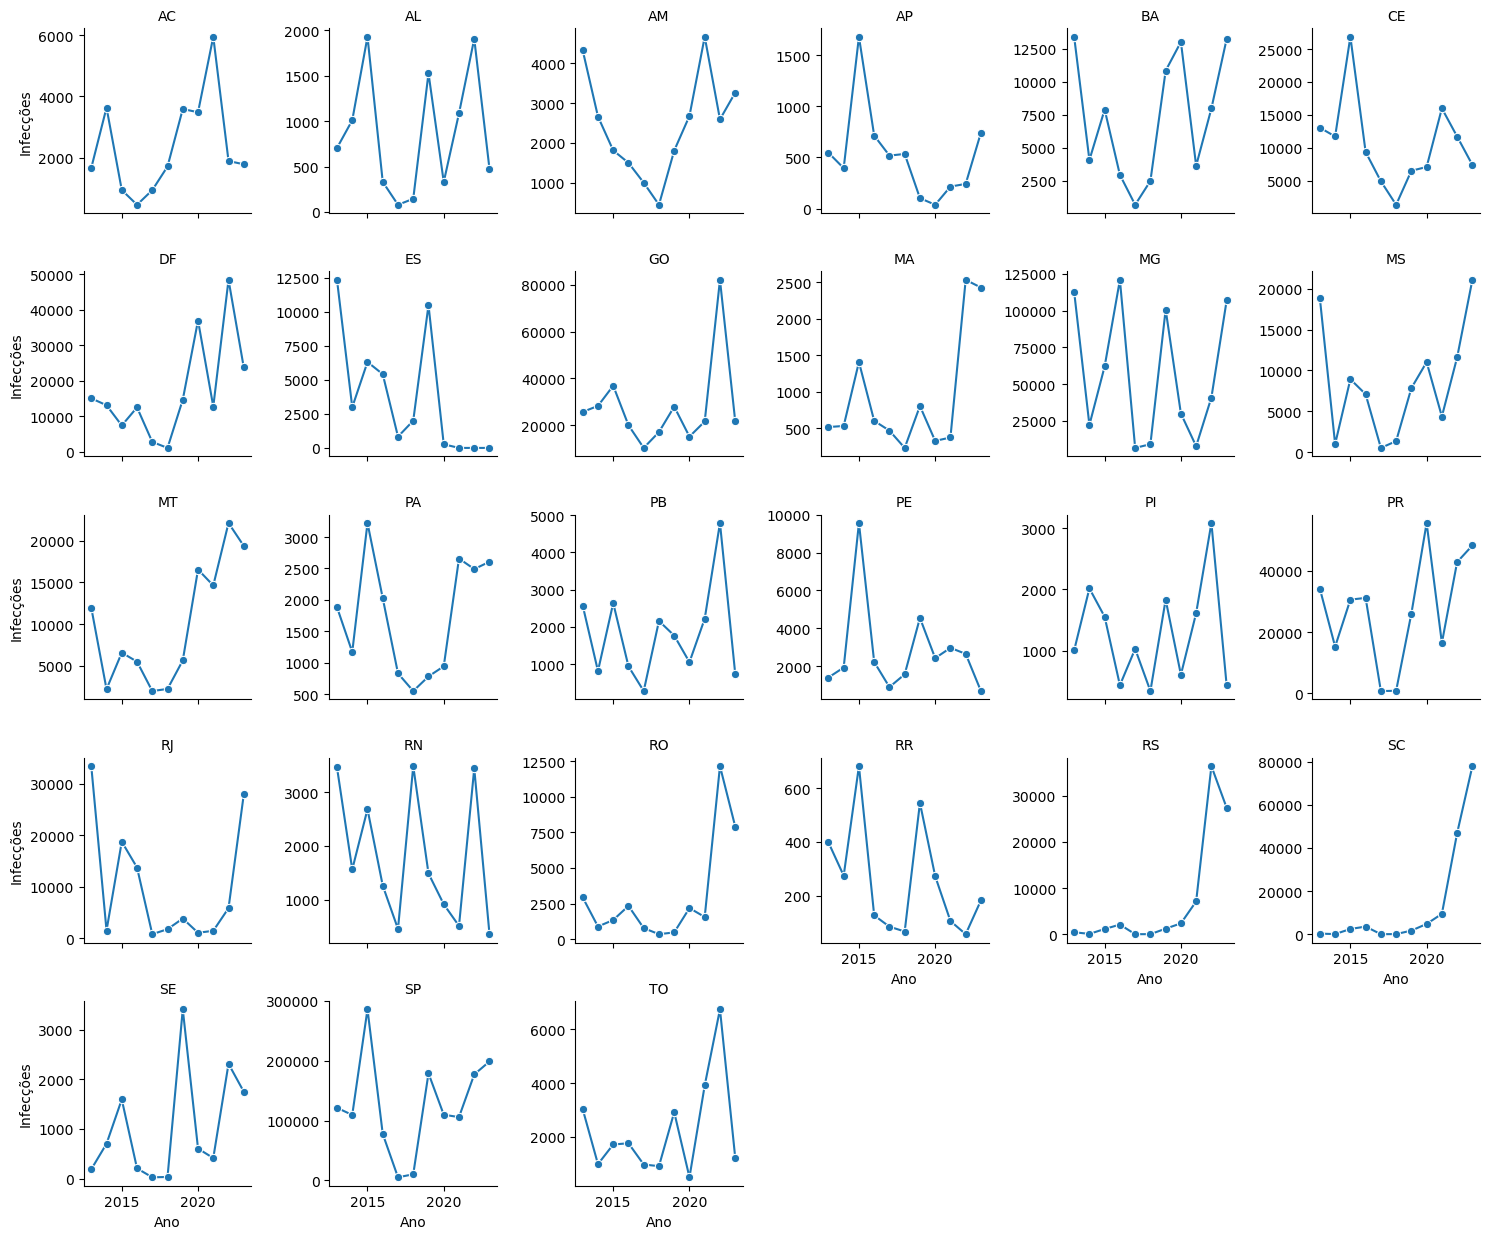

In [22]:
# Cria um gráfico de linha individual para cada estado
# col='uf' define que cada coluna do grid será um estado diferente
# col_wrap=6 limita a 6 gráficos por linha antes de quebrar para a próxima
# sharey=False permite que cada gráfico tenha sua própria escala no eixo Y
g = sns.FacetGrid(df_dengue_estado_completo, col='uf', col_wrap=6, height=2.5, sharey=False)

# Plota uma linha com marcadores para cada estado
g.map(sns.lineplot, 'ano', 'qtd_infeccoes', marker='o')

# Define o título de cada mini-gráfico como a sigla do estado
g.set_titles('{col_name}')
g.set_axis_labels('Ano', 'Infecções')

plt.tight_layout()
plt.show()
